# Overfitting — why a model can ace the test and still be wrong

Your first two notebooks quietly cheated. They measured accuracy on the **same 80
students they trained on** — like grading a student on the exact questions they were
allowed to study, with the answers next to them. Of course they score well.

The real question in machine learning is always: **how does the model do on data it has
never seen?** To find out, we hold some students back — a **validation set** the model
never trains on — and score against those.

This notebook shows the single most important idea in ML: **overfitting**. You'll watch
the training loss slide happily toward zero while the validation loss quietly turns
around and climbs — the model has stopped *learning* and started *memorizing*. Then
you'll fight it with two tools: **early stopping** and **regularization**.

Same student-admission data as before. Run top to bottom; the later sections have
**sliders** so you can make overfitting happen (and un-happen) with your own hands.

## 1. Setup

Same tools as the PyTorch notebook.

In [1]:
import csv
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["figure.dpi"] = 100

CMAP_PTS = ListedColormap(["#e8623c", "#2a9d8f"])   # points
CMAP_BG  = ListedColormap(["#fbe3da", "#d6efeb"])    # decision-boundary fill
C_TRAIN, C_VAL = "#3a86ff", "#e63946"                # train vs validation curves

print("torch", torch.__version__)

torch 2.12.1


## 2. Load the data and split it: train vs validation

Same `load_csv` / `normalize` as before. The new step is the **split**: we shuffle the
students and keep only a **small handful for training** (deliberately small, so
overfitting is easy to see), holding the rest back as a **validation set** the model
will never train on.

In the plot, **filled dots are the training set** and **hollow dots are the validation
set**. The model only ever sees the filled ones.

training on 20 students, validating on 60 held-out students


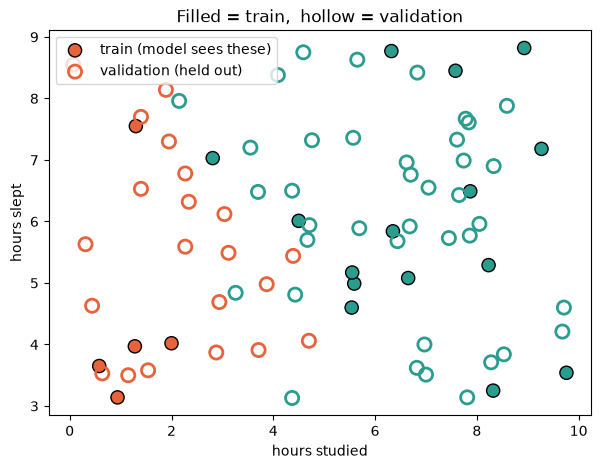

In [2]:
def find_data():
    for p in [Path("data.csv"), Path("simple_training/data.csv")]:
        if p.exists():
            return p
    raise FileNotFoundError("data.csv not found next to the notebook")

def load_csv(path):
    rows = list(csv.DictReader(open(path, newline="")))
    X = np.array([[float(r["hours_studied"]), float(r["hours_slept"])] for r in rows])
    y = np.array([[float(r["admitted"])] for r in rows])
    return X, y

def normalize(X):
    mean, std = X.mean(axis=0), X.std(axis=0)
    return (X - mean) / std, mean, std

X_raw, y = load_csv(find_data())
X, mean, std = normalize(X_raw)

def split(train_n, seed=0):
    # shuffle once, take the first train_n rows for training, the rest for validation
    idx = np.random.default_rng(seed).permutation(len(X))
    return idx[:train_n], idx[train_n:]

tr_idx, va_idx = split(train_n=20, seed=0)
print(f"training on {len(tr_idx)} students, validating on {len(va_idx)} held-out students")

fig, ax = plt.subplots()
ax.scatter(X_raw[tr_idx, 0], X_raw[tr_idx, 1], c=y[tr_idx].ravel(), cmap=CMAP_PTS,
           edgecolors="k", s=90, label="train (model sees these)")
ax.scatter(X_raw[va_idx, 0], X_raw[va_idx, 1], facecolors="none",
           edgecolors=[["#e8623c", "#2a9d8f"][int(v)] for v in y[va_idx].ravel()],
           s=90, linewidths=2, label="validation (held out)")
ax.set_xlabel("hours studied"); ax.set_ylabel("hours slept")
ax.set_title("Filled = train,  hollow = validation")
ax.legend(loc="upper left")
plt.show()

## 3. Train, but watch BOTH sets every epoch

The training loop is the familiar one — with a crucial addition. After each update we
measure the loss on **both** sets:

- **training loss** — how well it fits the data it learns from,
- **validation loss** — how well it does on the held-out data it never sees.

We deliberately give the model **plenty of capacity** (two hidden layers) and a **small
training set** — the perfect conditions to tempt it into memorizing.

A `label_noise` knob optionally flips a fraction of training labels (mislabeled
students). Real data is noisy, and noise makes overfitting even more dramatic: the model
will happily memorize the wrong answers.

In [3]:
def train_val(train_n=20, hidden_units=64, epochs=1500,
              weight_decay=0.0, label_noise=0.0, seed=0):
    g = np.random.default_rng(seed)
    idx = g.permutation(len(X))
    tr, va = idx[:train_n], idx[train_n:]

    Xtr, ytr = X[tr].copy(), y[tr].copy()
    if label_noise > 0:                       # flip some training labels
        k = int(label_noise * len(tr))
        flip = g.choice(len(tr), k, replace=False)
        ytr[flip] = 1 - ytr[flip]

    Xtr = torch.tensor(Xtr, dtype=torch.float32); ytr = torch.tensor(ytr, dtype=torch.float32)
    Xva = torch.tensor(X[va], dtype=torch.float32); yva = torch.tensor(y[va], dtype=torch.float32)

    torch.manual_seed(seed)
    model = nn.Sequential(
        nn.Linear(2, hidden_units), nn.ReLU(),
        nn.Linear(hidden_units, hidden_units), nn.ReLU(),
        nn.Linear(hidden_units, 1),
    )
    crit = nn.BCEWithLogitsLoss()
    # weight_decay is the regularization knob (Section 7); 0.0 = off
    opt = torch.optim.Adam(model.parameters(), lr=0.02, weight_decay=weight_decay)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(epochs):
        opt.zero_grad()
        loss = crit(model(Xtr), ytr)
        loss.backward()
        opt.step()
        with torch.no_grad():
            vloss = crit(model(Xva), yva).item()
            tacc = (((torch.sigmoid(model(Xtr)) > 0.5) == (ytr > 0.5)).float().mean().item())
            vacc = (((torch.sigmoid(model(Xva)) > 0.5) == (yva > 0.5)).float().mean().item())
        hist["train_loss"].append(loss.item()); hist["val_loss"].append(vloss)
        hist["train_acc"].append(tacc);        hist["val_acc"].append(vacc)
    return model, hist

def predict_proba(model, X_np):
    with torch.no_grad():
        return torch.sigmoid(model(torch.tensor(X_np, dtype=torch.float32))).numpy()

print("train_val() and predict_proba() defined")

train_val() and predict_proba() defined


## 4. The divergence — this is overfitting

Here is the whole lesson in one picture. Train the over-powered model and plot both
losses together:

- **Training loss (blue)** dives toward zero — the model is fitting its training data
  perfectly.
- **Validation loss (red)** drops at first (real learning!), then **turns around and
  climbs**.

That turning point is the moment learning stops and **memorizing** begins. After it, the
model keeps getting better at its training data and *worse* at everything else. The gap
between the two curves is the **generalization gap**.

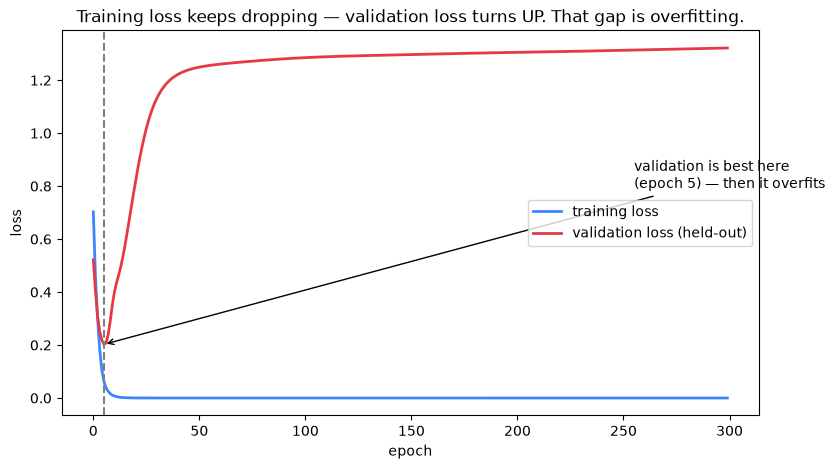

final training loss   0.000  (almost perfect on its own data)
final validation loss 1.322  (much worse on unseen data)
validation was best at epoch 5: loss 0.203, accuracy 92%


In [12]:
model, hist = train_val(train_n=20, hidden_units=64, epochs=300, seed=0)

best = int(np.argmin(hist["val_loss"]))
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hist["train_loss"], color=C_TRAIN, lw=2, label="training loss")
ax.plot(hist["val_loss"],   color=C_VAL,   lw=2, label="validation loss (held-out)")
ax.axvline(best, color="gray", ls="--")
ax.annotate(f"validation is best here\n(epoch {best}) — then it overfits",
            xy=(best, hist["val_loss"][best]),
            xytext=(best + 250, max(hist["val_loss"]) * 0.6),
            arrowprops=dict(arrowstyle="->"))
ax.set_xlabel("epoch"); ax.set_ylabel("loss")
ax.set_title("Training loss keeps dropping — validation loss turns UP. That gap is overfitting.")
ax.legend()
plt.show()

print(f"final training loss   {hist['train_loss'][-1]:.3f}  (almost perfect on its own data)")
print(f"final validation loss {hist['val_loss'][-1]:.3f}  (much worse on unseen data)")
print(f"validation was best at epoch {best}: loss {hist['val_loss'][best]:.3f}, "
      f"accuracy {hist['val_acc'][best]:.0%}")

## 5. What overfitting looks like on the map

The decision boundary makes it tangible. We snapshot the model at three moments:
**early** (barely trained), the **best validation epoch**, and the **end** (heavily
overfit). Watch the boundary go from a smooth, sensible line to a **contorted shape that
bends around individual training dots** — memorizing their exact positions, including
any noise.

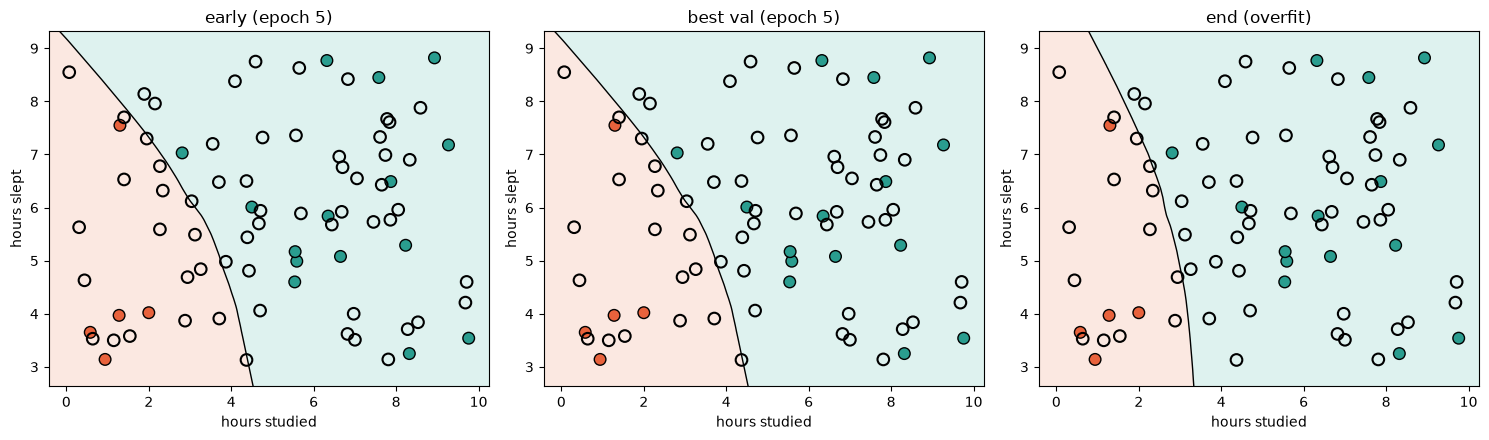

filled dots = training, hollow = held-out validation


In [5]:
def plot_decision_boundary(model, ax, title):
    xs = np.linspace(X_raw[:, 0].min() - 0.5, X_raw[:, 0].max() + 0.5, 200)
    ys = np.linspace(X_raw[:, 1].min() - 0.5, X_raw[:, 1].max() + 0.5, 200)
    gx, gy = np.meshgrid(xs, ys)
    grid_norm = (np.c_[gx.ravel(), gy.ravel()] - mean) / std
    probs = predict_proba(model, grid_norm).reshape(gx.shape)
    ax.contourf(gx, gy, probs, levels=[0, 0.5, 1], cmap=CMAP_BG, alpha=0.8)
    ax.contour(gx, gy, probs, levels=[0.5], colors="k", linewidths=1)
    ax.scatter(X_raw[tr_idx, 0], X_raw[tr_idx, 1], c=y[tr_idx].ravel(), cmap=CMAP_PTS,
               edgecolors="k", s=70)
    ax.scatter(X_raw[va_idx, 0], X_raw[va_idx, 1], facecolors="none", edgecolors="k",
               s=70, linewidths=1.5)
    ax.set_title(title); ax.set_xlabel("hours studied"); ax.set_ylabel("hours slept")

snapshots = [("early (epoch 5)", 5), (f"best val (epoch {best})", best), ("end (overfit)", 1500)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for (label, ep), ax in zip(snapshots, axes):
    m, _ = train_val(train_n=20, hidden_units=64, epochs=ep, seed=0)
    plot_decision_boundary(m, ax, label)
plt.tight_layout(); plt.show()
print("filled dots = training, hollow = held-out validation")

## 6. 🎛️ Make it overfit — and stop it — with your own hands

Now you drive it. Each change retrains and redraws the two loss curves, with a marker at
the **best validation epoch**.

- **train size** — *smaller* → easier to memorize → bigger gap.
- **hidden units** — *more* capacity → more room to overfit.
- **epochs** — train longer and watch validation loss climb past its minimum.
- **weight decay** — the fix: turn it up and watch the red curve flatten (Section 7).
- **label noise** — mislabel some training students; the model memorizes the mistakes.

**Try:** start with the defaults (a clear U-turn). Then drag **weight decay** up to ~0.05
and watch the gap collapse. Then set weight decay back to 0 and raise **label noise** —
the gap explodes.

In [6]:
def explore(train_n, hidden_units, epochs, weight_decay, label_noise):
    model, hist = train_val(train_n, hidden_units, epochs, weight_decay, label_noise, seed=0)
    best = int(np.argmin(hist["val_loss"]))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(hist["train_loss"], color=C_TRAIN, lw=2, label="training loss")
    ax.plot(hist["val_loss"],   color=C_VAL,   lw=2, label="validation loss")
    ax.axvline(best, color="gray", ls="--", label=f"best val @ epoch {best}")
    ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.set_ylim(bottom=0)
    gap = hist["val_loss"][-1] - hist["train_loss"][-1]
    ax.set_title(f"generalization gap at the end: {gap:.2f}   "
                 f"(best val loss {hist['val_loss'][best]:.2f}, acc {hist['val_acc'][best]:.0%})")
    ax.legend()
    plt.show()

interact(
    explore,
    train_n=IntSlider(value=20, min=10, max=70, step=2, description="train size"),
    hidden_units=IntSlider(value=64, min=2, max=128, step=2, description="hidden units"),
    epochs=IntSlider(value=1500, min=50, max=3000, step=50, description="epochs"),
    weight_decay=FloatSlider(value=0.0, min=0.0, max=0.2, step=0.005,
                             readout_format=".3f", description="weight decay"),
    label_noise=FloatSlider(value=0.0, min=0.0, max=0.4, step=0.05,
                            readout_format=".2f", description="label noise"),
);

interactive(children=(IntSlider(value=20, description='train size', max=70, min=10, step=2), IntSlider(value=6…

## 7. Fix #1 — early stopping

The simplest defense is written on the plot already: the model was at its best at the
dashed line, *before* validation loss started rising. **Early stopping** just means:
keep an eye on validation loss and **stop training at its minimum**, not at the end.

You keep the well-generalizing model and throw away the memorizing epochs that came
after. It's free — you were computing validation loss anyway.

In [7]:
_, h = train_val(train_n=20, hidden_units=64, epochs=1500, seed=0)
best = int(np.argmin(h["val_loss"]))
print(f"if we stop at the best epoch ({best}):")
print(f"    validation loss {h['val_loss'][best]:.3f},  accuracy {h['val_acc'][best]:.0%}")
print(f"if we train all the way to the end (epoch 1499):")
print(f"    validation loss {h['val_loss'][-1]:.3f},  accuracy {h['val_acc'][-1]:.0%}")
print("\nTraining longer made the model WORSE on unseen data. Stopping early wins.")

if we stop at the best epoch (5):
    validation loss 0.203,  accuracy 92%
if we train all the way to the end (epoch 1499):
    validation loss 1.444,  accuracy 88%

Training longer made the model WORSE on unseen data. Stopping early wins.


## 8. Fix #2 — regularization (weight decay)

Overfitting shows up as wildly large, contorted weights (that's how the boundary gets so
wiggly). **Weight decay** adds a penalty for large weights to the loss, gently pulling
them toward zero — so the model prefers *simpler* explanations unless the data really
demands complexity.

Same over-powered model, trained twice: without and with weight decay. Watch the
validation curve flatten out.

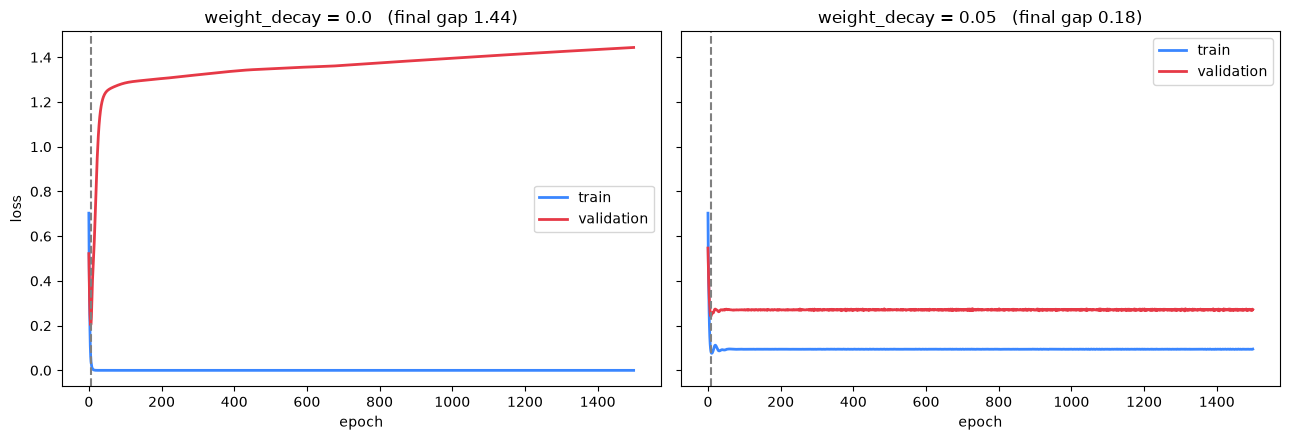

Left: no regularization — validation loss blows up.
Right: a little weight decay — validation stays low, gap nearly gone.


In [8]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, wd in [(a0, 0.0), (a1, 0.05)]:
    _, h = train_val(train_n=20, hidden_units=64, epochs=1500, weight_decay=wd, seed=0)
    b = int(np.argmin(h["val_loss"]))
    ax.plot(h["train_loss"], color=C_TRAIN, lw=2, label="train")
    ax.plot(h["val_loss"],   color=C_VAL,   lw=2, label="validation")
    ax.axvline(b, color="gray", ls="--")
    gap = h["val_loss"][-1] - h["train_loss"][-1]
    ax.set_title(f"weight_decay = {wd}   (final gap {gap:.2f})")
    ax.set_xlabel("epoch"); ax.legend()
a0.set_ylabel("loss")
plt.tight_layout(); plt.show()
print("Left: no regularization — validation loss blows up.")
print("Right: a little weight decay — validation stays low, gap nearly gone.")

## 9. Recap — the most important idea in ML

- A model that scores well on its **training data** may be **memorizing**, not learning.
  Always judge it on **held-out validation data**.
- **Overfitting** is when training loss keeps falling while validation loss rises. The
  distance between them is the **generalization gap**.
- It gets worse with **small data**, **too much model capacity**, **training too long**,
  and **noisy labels** — you saw each of these move the gap.
- Two fixes you used: **early stopping** (quit at the best validation epoch) and
  **regularization / weight decay** (penalize complexity).

From here on, every serious model you meet — image classifiers, language models — is
trained with exactly this train/validation discipline. It's the difference between a
model that works and one that only *looks* like it works.

**Your next rung:** leave this two-column spreadsheet behind and train on **images**.
The same ideas (loss, gradients, train/validation) carry over, plus a new ingredient —
**convolutions** — built for pictures. That's where `01_intro.ipynb` in this repo picks
up: an image classifier in a handful of lines.